In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [25]:
df = pd.read_csv("/content/drive/MyDrive/iStudio/Data Science/loan_data_set_lyst1728376986423.csv")

In [26]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [28]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [29]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [30]:
# Target column is 'Loan_Status' (i.e., 'Y' or 'N')

target_col = 'Loan_Status'

In [31]:
# Filling missing numbers with the median, and missing text/categories with the mode (most frequent)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [32]:
# also drop things like 'Loan_ID' because it doesn't help predict anything

if 'Loan_ID' in df.columns:
    X = df.drop(['Loan_ID', target_col], axis=1)
else:
    X = df.drop(target_col, axis=1)

y = df[target_col]

In [33]:
# Convert the target variable to 1s and 0s if it's currently text (like 'Y'/'N')
# Update 'Y' to whatever represents your positive outcome (e.g., 'Approved', 'Yes')

y = y.apply(lambda x: 1 if x == 'Y' else 0)

In [34]:
# Convert Categorical Text to Numbers
# This turns columns like "Gender" into numerical columns like "Gender_Male" (1 or 0)

X = pd.get_dummies(X, drop_first=True)

In [35]:
# Split into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# Scaling ensures large numbers (like Income) don't overpower small numbers (like Credit History)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
# Train the Logistic Regression Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

 🏦 LOAN PREDICTION MODEL REPORT
✅ Overall Model Accuracy: 78.86%

--------------------------------------------------
 DETAILED METRICS
--------------------------------------------------
              precision  recall  f1-score  support
Denied (0)         0.95    0.42      0.58    43.00
Approved (1)       0.76    0.99      0.86    80.00
accuracy           0.79    0.79      0.79     0.79
macro avg          0.85    0.70      0.72   123.00
weighted avg       0.83    0.79      0.76   123.00




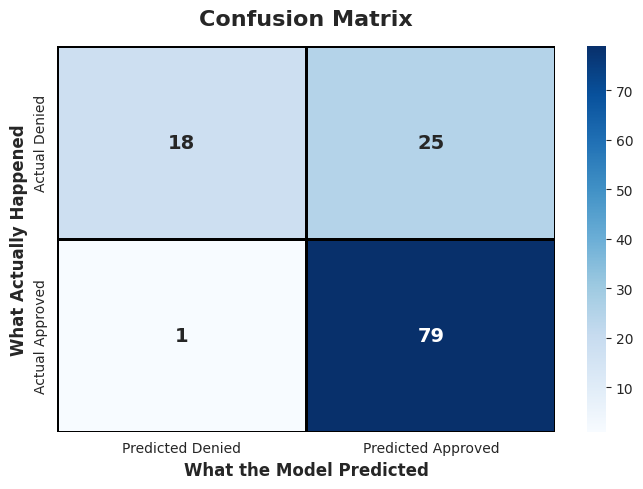

In [40]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# ==========================================
# 📊 1. REPORT HEADER & ACCURACY
# ==========================================
print("=" * 50)
print(" 🏦 LOAN PREDICTION MODEL REPORT")
print("=" * 50)

# Print accuracy formatted as a percentage
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Overall Model Accuracy: {accuracy:.2%}\n")

# ==========================================
# 📋 2. CLEAN CLASSIFICATION REPORT
# ==========================================
print("-" * 50)
print(" DETAILED METRICS")
print("-" * 50)

# Convert the report to a dictionary, then to a Pandas DataFrame for a clean table look
# (Assuming 0 = Denied/No, 1 = Approved/Yes)
report_dict = classification_report(y_test, y_pred, output_dict=True, target_names=['Denied (0)', 'Approved (1)'])
report_df = pd.DataFrame(report_dict).transpose()


print(report_df.round(2).to_string())
print("\n")

# ==========================================
# 🗺️ 3. AESTHETIC CONFUSION MATRIX HEATMAP
# ==========================================
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the visual plot
plt.figure(figsize=(7, 5))
sns.set_style("whitegrid") # Adds a clean background

# Create the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=1, linecolor='black',
            xticklabels=['Predicted Denied', 'Predicted Approved'],
            yticklabels=['Actual Denied', 'Actual Approved'],
            annot_kws={"size": 14, "weight": "bold"}) # Makes the numbers pop

# Add labels and title
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('What the Model Predicted', fontsize=12, fontweight='bold')
plt.ylabel('What Actually Happened', fontsize=12, fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()

In [41]:
# ==========================================
# 📝 4. AUTOMATED BUSINESS SUMMARY
# ==========================================
# Extract numbers from the confusion matrix
tn, fp, fn, tp = cm.ravel()
total_loans = tn + fp + fn + tp

print("=" * 50)
print(" 💡 EXECUTIVE BUSINESS SUMMARY")
print("=" * 50)

# 1. High-Level Performance
print(f"🔹 OVERALL PERFORMANCE:")
print(f"Out of {total_loans} historical loans tested, the model correctly predicted {tn + tp} of them.")
print(f"This gives us an overall confidence rate of {accuracy:.2%}.\n")

# 2. Analyzing the "Good" (Correct Predictions)
print(f"🔹 THE GOOD (Correct Predictions):")
print(f" - Correctly Approved: {tp} safe loans were properly identified.")
print(f" - Correctly Denied: {tn} risky loans were properly avoided.\n")

# 3. Analyzing the "Bad" (Business Risks)
print(f"🔹 THE RISKS (Model Errors):")
print(f" - ⚠️ Risk of Default (False Positives): {fp} loans were predicted as 'Approved' but actually defaulted/were denied. This is a direct financial risk.")
print(f" - 💸 Lost Business (False Negatives): {fn} loans were predicted as 'Denied' but were actually good loans. This represents lost revenue.\n")

# 4. Actionable Conclusion based on the numbers
if fp > fn:
    print("📌 CONCLUSION: The model is currently overly optimistic. It is approving too many bad loans (high False Positives). We may need to use stricter thresholds to reduce financial risk.")
elif fn > fp:
    print("📌 CONCLUSION: The model is currently overly strict. It is rejecting too many good customers (high False Negatives). We might want to relax the rules to capture more revenue.")
else:
    print("📌 CONCLUSION: The model is balanced equally between false approvals and false rejections.")

print("=" * 50)

 💡 EXECUTIVE BUSINESS SUMMARY
🔹 OVERALL PERFORMANCE:
Out of 123 historical loans tested, the model correctly predicted 97 of them.
This gives us an overall confidence rate of 78.86%.

🔹 THE GOOD (Correct Predictions):
 - Correctly Approved: 79 safe loans were properly identified.
 - Correctly Denied: 18 risky loans were properly avoided.

🔹 THE RISKS (Model Errors):
 - ⚠️ Risk of Default (False Positives): 25 loans were predicted as 'Approved' but actually defaulted/were denied. This is a direct financial risk.
 - 💸 Lost Business (False Negatives): 1 loans were predicted as 'Denied' but were actually good loans. This represents lost revenue.

📌 CONCLUSION: The model is currently overly optimistic. It is approving too many bad loans (high False Positives). We may need to use stricter thresholds to reduce financial risk.
